# 导入类库和数据

In [11]:
# 导入类库
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt

import time
start =time.time()

# 1) 导入数据
categories = ['alt.atheism',
              'rec.sport.hockey',
              'comp.graphics',
              'sci.crypt',
              'comp.os.ms-windows.misc',
              'sci.electronics',
              'comp.sys.ibm.pc.hardware',
              'sci.med',
              'comp.sys.mac.hardware',
              'sci.space',
              'comp.windows.x',
              'soc.religion.christian',
              'misc.forsale',
              'talk.politics.guns',
              'rec.autos' 
              'talk.politics.mideast',
              'rec.motorcycles',
              'talk.politics.misc',
              'rec.sport.baseball',
              'talk.religion.misc']

# 导入训练数据
train_path = '20news-bydate-train'
dataset_train = load_files(container_path = train_path, categories = categories)
# 导入评估数据
test_path = '20news-bydate-test'
dataset_test = load_files(container_path = test_path, categories = categories)

finish = time.time()
print("耗时(秒)：", finish - start)

# print(dataset_train.data[:3])
# print(dataset_train.target[:3])

耗时(秒)： 3.417973518371582


# 优化显示

In [3]:
# 优化
# 1.不显示错误警告
import warnings
warnings.filterwarnings('ignore')

# 2.画图过程中的中文显示
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False     # 修复负号显示问题

# 数据处理成可计算的形式

### 统计词频

In [16]:
# 2）数据准备与理解

# 计算词频
count_vect = CountVectorizer(stop_words = 'english', decode_error = 'ignore')
X_train_counts = count_vect.fit_transform(dataset_train.data)

# 查看数据维度
print(X_train_counts.shape)
print(X_train_counts)

(10156, 122402)
  (0, 42345)	1
  (0, 54844)	1
  (0, 92123)	1
  (0, 27435)	4
  (0, 38742)	1
  (0, 42344)	2
  (0, 24828)	2
  (0, 104689)	1
  (0, 58919)	1
  (0, 63498)	1
  (0, 93360)	1
  (0, 36447)	2
  (0, 15683)	2
  (0, 84961)	1
  (0, 39221)	2
  (0, 71388)	1
  (0, 8602)	1
  (0, 28071)	1
  (0, 34347)	1
  (0, 15035)	1
  (0, 79876)	1
  (0, 24399)	1
  (0, 114326)	2
  (0, 47594)	2
  (0, 65817)	1
  :	:
  (10155, 63783)	1
  (10155, 84946)	3
  (10155, 102841)	1
  (10155, 117615)	1
  (10155, 10636)	1
  (10155, 111765)	1
  (10155, 47715)	1
  (10155, 38154)	1
  (10155, 24415)	3
  (10155, 87426)	1
  (10155, 51542)	1
  (10155, 8485)	1
  (10155, 67477)	1
  (10155, 74005)	2
  (10155, 109199)	1
  (10155, 76913)	1
  (10155, 25217)	3
  (10155, 48002)	1
  (10155, 70161)	4
  (10155, 5108)	1
  (10155, 25199)	3
  (10155, 24412)	1
  (10155, 50289)	1
  (10155, 99654)	1
  (10155, 32842)	3


### TF-IDF

In [18]:
# 计算TF-IDF
tf_transformer = TfidfVectorizer(stop_words = 'english', decode_error = 'ignore')
X_train_counts_tf = tf_transformer.fit_transform(dataset_train.data)

# 查看数据维度
print(X_train_counts_tf.shape)
# print(X_train_counts_tf)

(10156, 122402)
  (0, 94194)	0.1041859355499632
  (0, 30301)	0.11039345501558663
  (0, 71263)	0.0311301719185464
  (0, 106583)	0.08552910447500749
  (0, 42896)	0.0853330489982842
  (0, 50015)	0.06052214753697959
  (0, 109475)	0.05971010987829231
  (0, 117538)	0.04353254581031619
  (0, 117632)	0.05922488372276063
  (0, 108632)	0.06083886040137888
  (0, 109688)	0.049477303966710844
  (0, 24768)	0.04983756911258481
  (0, 44380)	0.04425703231168687
  (0, 41560)	0.21480280364932217
  (0, 52180)	0.06094599736518051
  (0, 95231)	0.08909422044044747
  (0, 77312)	0.08439089290137619
  (0, 51299)	0.07030295845275866
  (0, 72008)	0.04767086747470714
  (0, 116585)	0.09014267220383501
  (0, 76199)	0.06041810480880318
  (0, 112529)	0.042529806513069146
  (0, 113678)	0.04140639198532269
  (0, 90337)	0.08963899103297042
  (0, 44436)	0.061272272177675384
  :	:
  (10155, 35098)	0.04174725410010064
  (10155, 36927)	0.06248433007457363
  (10155, 31127)	0.05002055845473479
  (10155, 94193)	0.07868606474201

# 设置评估参数
分离X、Y，分离训练集和测试集，这些在读入数据的时候就做了，所以这里不用做了

In [6]:
# 设置评估算法的基准
num_folds = 10
seed = 7
scoring = 'accuracy'

# 单一模型
5种算法；
注意：样本数和维度都大，所以算力消耗变大

LR : 0.904193 (0.008237)
SVM : 0.906065 (0.008374)
CART : 0.657442 (0.019375)
MNB : 0.881349 (0.011071)
KNN : 0.795983 (0.010343)


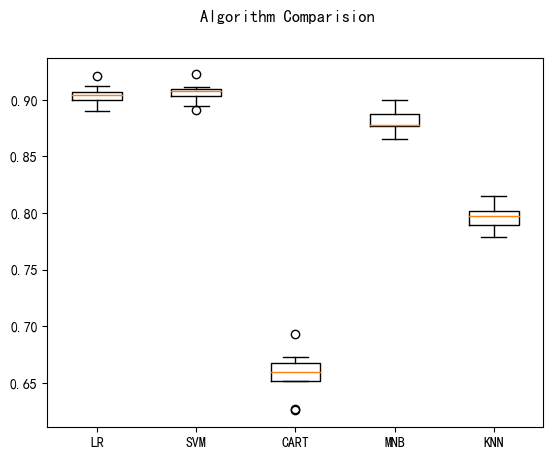

耗时(秒)： 2959.6054134368896


In [6]:
import time
start = time.time()

# 3）评估算法
# 生成算法模型
models = {}
models['LR']   = LogisticRegression()
models['SVM']  = SVC()
models['CART'] = DecisionTreeClassifier()
models['MNB']  = MultinomialNB() # 多项式朴素贝叶斯，处理离散特征
models['KNN']  = KNeighborsClassifier()

# 比较算法
results = []
for key in models:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_results = cross_val_score(models[key], X_train_counts_tf, dataset_train.target, cv = kfold, scoring = scoring)
    results.append(cv_results)
    print('%s : %f (%f)' % (key, cv_results.mean(), cv_results.std()))

# 箱线图比较算法
fig = plt.figure()
fig.suptitle('Algorithm Comparision')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(models.keys())
plt.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 调参
LR、SVM和MNB三个方法相对好，注意对比，MNB用时明显短了很多

### LR调参

In [7]:
import time
start = time.time()

# 4）算法调参
# 调参LR
param_grid = {}
param_grid['C'] = [0.1, 5, 13, 15]
model = LogisticRegression()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = X_train_counts_tf, y = dataset_train.target)
print('最优 : %s 使用 %s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优 : 0.9235900469337885 使用 {'C': 15}
耗时(秒)： 1440.550422668457


### SVM调参

In [ ]:
import time
start = time.time()

# 调参SVM
param_grid = {}
param_grid['C'] = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.5, 1.7, 2.0]
param_grid['kernel'] = ['linear', 'poly', 'rbf', 'sigmoid']

model = SVC()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = X_train_counts_tf, y = dataset_train.target)
print('最优 : %s 使用 %s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

### MNB调参

In [8]:
import time
start = time.time()

# 调参MNB
param_grid = {}
param_grid['alpha'] = [0.001, 0.01, 0.1, 1.5]
model = MultinomialNB()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = X_train_counts_tf, y = dataset_train.target)
print('最优 : %s 使用 %s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优 : 0.9153203909856096 使用 {'alpha': 0.01}
耗时(秒)： 4.840975761413574


# 集成算法
装袋算法（随机森林）、提升算法（adaboost）

RF : 0.859783 (0.011201)
AB : 0.558879 (0.016715)


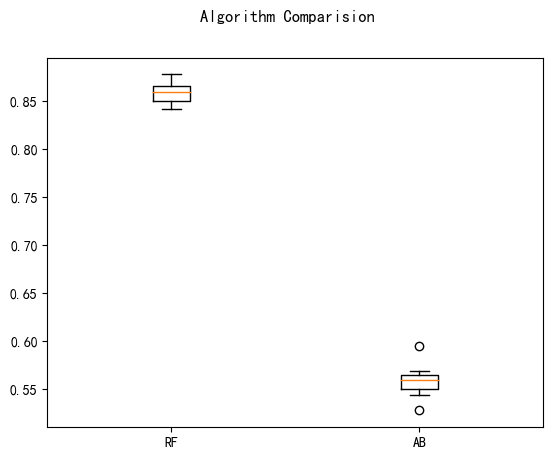

耗时(秒)： 3885.193258047104


In [9]:
import time
start =time.time()

# 5）集成算法
ensembles = {}
ensembles['RF'] = RandomForestClassifier()
ensembles['AB'] = AdaBoostClassifier()
# 比较集成算法
results = []
for key in ensembles:
    kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
    cv_results = cross_val_score(ensembles[key], X_train_counts_tf, dataset_train.target, cv = kfold, scoring = scoring)
    results.append(cv_results)
    print('%s : %f (%f)' % (key, cv_results.mean(), cv_results.std()))

# 箱线图比较算法
fig = plt.figure()
fig.suptitle('Algorithm Comparision')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(ensembles.keys())
plt.show()

finish = time.time()
print("耗时(秒)：", finish - start)

# 集成算法调参
随机森林效果明显较好，进一步做调参优化；计算量很大，13574秒约226分钟

In [7]:
import time
start = time.time()

# 调参RF
param_grid = {}
param_grid['n_estimators'] = [10, 100, 150, 200]

model = RandomForestClassifier()
kfold = KFold(n_splits = num_folds, shuffle = True, random_state = seed)
grid = GridSearchCV(estimator = model, param_grid = param_grid, scoring = scoring, cv = kfold)
grid_result = grid.fit(X = X_train_counts_tf, y = dataset_train.target)
print('最优 : %s 使用 %s' % (grid_result.best_score_, grid_result.best_params_))

finish = time.time()
print("耗时(秒)：", finish - start)

最优 : 0.8703200031030605 使用 {'n_estimators': 200}
耗时(秒)： 13574.644881486893


# 确定模型
最后最好的是逻辑回归

In [7]:
# 6）生成模型
model = LogisticRegression(C = 15)
model.fit(X_train_counts_tf, dataset_train.target)
X_test_counts = tf_transformer.transform(dataset_test.data)
predictions = model.predict(X_test_counts)
print(accuracy_score(dataset_test.target, predictions))
print(classification_report(dataset_test.target, predictions))

0.8431952662721893
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       319
           1       0.73      0.81      0.77       389
           2       0.76      0.74      0.75       394
           3       0.71      0.75      0.73       392
           4       0.82      0.85      0.83       385
           5       0.85      0.76      0.81       395
           6       0.83      0.91      0.86       390
           7       0.96      0.97      0.97       398
           8       0.92      0.94      0.93       397
           9       0.97      0.97      0.97       399
          10       0.96      0.92      0.94       396
          11       0.79      0.79      0.79       393
          12       0.91      0.87      0.89       396
          13       0.92      0.92      0.92       394
          14       0.86      0.92      0.89       398
          15       0.75      0.90      0.82       364
          16       0.87      0.62      0.72       310
        